In [1]:
import pandas as pd
from sqlalchemy import create_engine, inspect

from pathlib import Path

# Project root — adjust once, use everywhere
BASE_DIR = Path(r"D:\code\mf-analysis")

DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"
DB_PATH = BASE_DIR / "data" / "db" / "bluestockmf.db"
REPORTS_DIR = BASE_DIR / "reports"

engine = create_engine(f"sqlite:///{DB_PATH}")
inspector = inspect(engine)
print(inspector.get_table_names())

['dim_date', 'dim_fund', 'fact_aum', 'fact_nav', 'fact_performance', 'fact_portfolio', 'fact_sip_industry', 'fact_transactions']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sqlalchemy import create_engine

sns.set_style("whitegrid")

# Pull tables (note: no parse_dates here since dates live in dim_date, not these tables)
fund_master = pd.read_sql("SELECT * FROM dim_fund", engine)
dim_date = pd.read_sql("SELECT * FROM dim_date", engine, parse_dates=["full_date"])
nav = pd.read_sql("SELECT * FROM fact_nav", engine)
aum = pd.read_sql("SELECT * FROM fact_aum", engine)
txn = pd.read_sql("SELECT * FROM fact_transactions", engine)
sip = pd.read_sql("SELECT * FROM fact_sip_industry", engine)
holdings = pd.read_sql("SELECT * FROM fact_portfolio", engine)

# NOT in DB yet — load from raw/processed CSVs
folio = pd.read_csv(DATA_RAW / "06_industry_folio_count.csv")
category_inflows = pd.read_csv(DATA_RAW / "05_category_inflows.csv")

# Merge date_id -> actual date for every table that has it
nav = nav.merge(dim_date[["date_id","full_date"]], on="date_id", how="left")
aum = aum.merge(dim_date[["date_id","full_date"]], on="date_id", how="left")
txn = txn.merge(dim_date[["date_id","full_date"]], on="date_id", how="left")
sip = sip.merge(dim_date[["date_id","full_date"]], on="date_id", how="left")
holdings = holdings.merge(dim_date[["date_id","full_date"]], on="date_id", how="left")

# Merge fund metadata into nav for easy labeling
nav = nav.merge(fund_master[["amfi_code","scheme_name","fund_house","category"]], on="amfi_code", how="left")

print("Shapes after merge:")
for name, df in [("nav",nav),("aum",aum),("txn",txn),("sip",sip),("holdings",holdings)]:
    print(name, df.shape, "| nulls in full_date:", df["full_date"].isna().sum())

Shapes after merge:
nav (64320, 8) | nulls in full_date: 0
aum (90, 4) | nulls in full_date: 0
txn (0, 9) | nulls in full_date: 0
sip (48, 7) | nulls in full_date: 0
holdings (322, 6) | nulls in full_date: 0


In [3]:
print(pd.read_sql("SELECT COUNT(*) FROM fact_aum", engine))
print(pd.read_sql("SELECT * FROM fact_aum LIMIT 5", engine))

   COUNT(*)
0        90
            fund_house  date_id  aum_crore
0      SBI Mutual Fund    17776     605000
1  ICICI Prudential MF    17776     465000
2     HDFC Mutual Fund    17776     435000
3      Nippon India MF    17776     270000
4    Kotak Mahindra MF    17776     270000


In [4]:
import os

# What file is this notebook actually connected to?
print("Notebook's db path:", os.path.abspath("../bluestockmf.db"))
print("Does it exist?", os.path.exists("../bluestockmf.db"))

# Search nearby folders for ALL .db files that exist
print("\nAll .db files found nearby:")
for root, dirs, files in os.walk(".."):
    for f in files:
        if f.endswith(".db"):
            full_path = os.path.join(root, f)
            size_kb = os.path.getsize(full_path) / 1024
            print(f"{full_path}  ({size_kb:.1f} KB)")

Notebook's db path: d:\code\mf-analysis\bluestockmf.db
Does it exist? True

All .db files found nearby:
..\bluestockmf.db  (0.0 KB)
..\data\db\bluestockmf.db  (4496.0 KB)


In [5]:
import pandas as pd
aum_raw = pd.read_csv(DATA_RAW / "03_aum_by_fund_house.csv")
print(aum_raw.columns.tolist())
print(aum_raw.head())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


In [6]:
# ---- Read raw CSV ----
aum_raw = pd.read_csv(DATA_RAW/"03_aum_by_fund_house.csv")

In [7]:
# ----  Convert date column to datetime ----
aum_raw["date"] = pd.to_datetime(aum_raw["date"])

In [8]:
# ----Load dim_date for the lookup ----
dim_date = pd.read_sql("SELECT date_id, full_date FROM dim_date", engine)
dim_date["full_date"] = pd.to_datetime(dim_date["full_date"])

In [9]:
# ---- Merge to get date_id ----
aum_merged = aum_raw.merge(dim_date, left_on="date", right_on="full_date", how="left")
print(aum_merged[["date","date_id"]].head(10))
print("Nulls in date_id:", aum_merged["date_id"].isna().sum())

        date  date_id
0 2022-03-31    17776
1 2022-03-31    17776
2 2022-03-31    17776
3 2022-03-31    17776
4 2022-03-31    17776
5 2022-03-31    17776
6 2022-03-31    17776
7 2022-03-31    17776
8 2022-03-31    17776
9 2022-03-31    17776
Nulls in date_id: 0


In [10]:
# If aum_final isn't in memory anymore (kernel was restarted), rebuild it:
aum_raw = pd.read_csv(DATA_RAW / "03_aum_by_fund_house.csv")
aum_raw["date"] = pd.to_datetime(aum_raw["date"])

dim_date = pd.read_sql("SELECT date_id, full_date FROM dim_date", engine)
dim_date["full_date"] = pd.to_datetime(dim_date["full_date"])

aum_merged = pd.merge_asof(
    aum_raw.sort_values("date"), 
    dim_date.sort_values("full_date"), 
    left_on="date", right_on="full_date", 
    direction="nearest"
)

aum_final = aum_merged[["fund_house", "date_id", "aum_crore"]]
print(aum_final.shape)

(90, 3)


In [11]:
aum_final.to_sql("fact_aum", engine, if_exists="replace", index=False)

print(pd.read_sql("SELECT COUNT(*) FROM fact_aum", engine))
print(pd.read_sql("SELECT * FROM fact_aum LIMIT 5", engine))

   COUNT(*)
0        90
            fund_house  date_id  aum_crore
0      SBI Mutual Fund    17776     605000
1  ICICI Prudential MF    17776     465000
2     HDFC Mutual Fund    17776     435000
3      Nippon India MF    17776     270000
4    Kotak Mahindra MF    17776     270000


In [12]:
from sqlalchemy import inspect

inspector = inspect(engine)
print("All tables:", inspector.get_table_names())

print("\n--- Row counts ---")
for table in inspector.get_table_names():
    count = pd.read_sql(f"SELECT COUNT(*) as cnt FROM {table}", engine)["cnt"][0]
    print(f"{table}: {count} rows")

All tables: ['dim_date', 'dim_fund', 'fact_aum', 'fact_nav', 'fact_performance', 'fact_portfolio', 'fact_sip_industry', 'fact_transactions']

--- Row counts ---
dim_date: 1608 rows
dim_fund: 40 rows
fact_aum: 90 rows
fact_nav: 64320 rows
fact_performance: 40 rows
fact_portfolio: 322 rows
fact_sip_industry: 48 rows
fact_transactions: 0 rows


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [14]:
sns.set_style("whitegrid")

# Load all 8 tables
fund_master = pd.read_sql("SELECT * FROM dim_fund", engine)
dim_date = pd.read_sql("SELECT * FROM dim_date", engine, parse_dates=["full_date"])
nav = pd.read_sql("SELECT * FROM fact_nav", engine)
aum = pd.read_sql("SELECT * FROM fact_aum", engine)
txn = pd.read_sql("SELECT * FROM fact_transactions", engine)
performance = pd.read_sql("SELECT * FROM fact_performance", engine)
holdings = pd.read_sql("SELECT * FROM fact_portfolio", engine)
sip = pd.read_sql("SELECT * FROM fact_sip_industry", engine)

# Merge date_id -> actual date for every table that needs it
nav = nav.merge(dim_date[["date_id","full_date"]], on="date_id", how="left")
aum = aum.merge(dim_date[["date_id","full_date"]], on="date_id", how="left")
txn = txn.merge(dim_date[["date_id","full_date"]], on="date_id", how="left")
sip = sip.merge(dim_date[["date_id","full_date"]], on="date_id", how="left")
holdings = holdings.merge(dim_date[["date_id","full_date"]], on="date_id", how="left")

# Merge fund metadata into nav for labeling charts
nav = nav.merge(fund_master[["amfi_code","scheme_name","fund_house","category"]], on="amfi_code", how="left")

print("Setup complete. Shapes:")
for name, df in [("nav",nav),("aum",aum),("txn",txn),("sip",sip),("holdings",holdings),("performance",performance)]:
    print(name, df.shape)

Setup complete. Shapes:
nav (64320, 8)
aum (90, 4)
txn (0, 9)
sip (48, 7)
holdings (322, 6)
performance (40, 17)


In [15]:
import plotly.express as px

fig = px.line(nav, x="full_date", y="nav", color="scheme_name",
              title="NAV Trend — All 40 Schemes (2022–2026)")
fig.update_layout(showlegend=False)

fig.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.1,
              annotation_text="2023 Bull Run", annotation_position="top left")
fig.add_vrect(x0="2024-01-01", x1="2024-12-31", fillcolor="red", opacity=0.1,
              annotation_text="2024 Correction", annotation_position="top left")

fig.show()
plt.savefig(REPORTS_DIR / "01_nav_trend.png", dpi=150)

<Figure size 640x480 with 0 Axes>

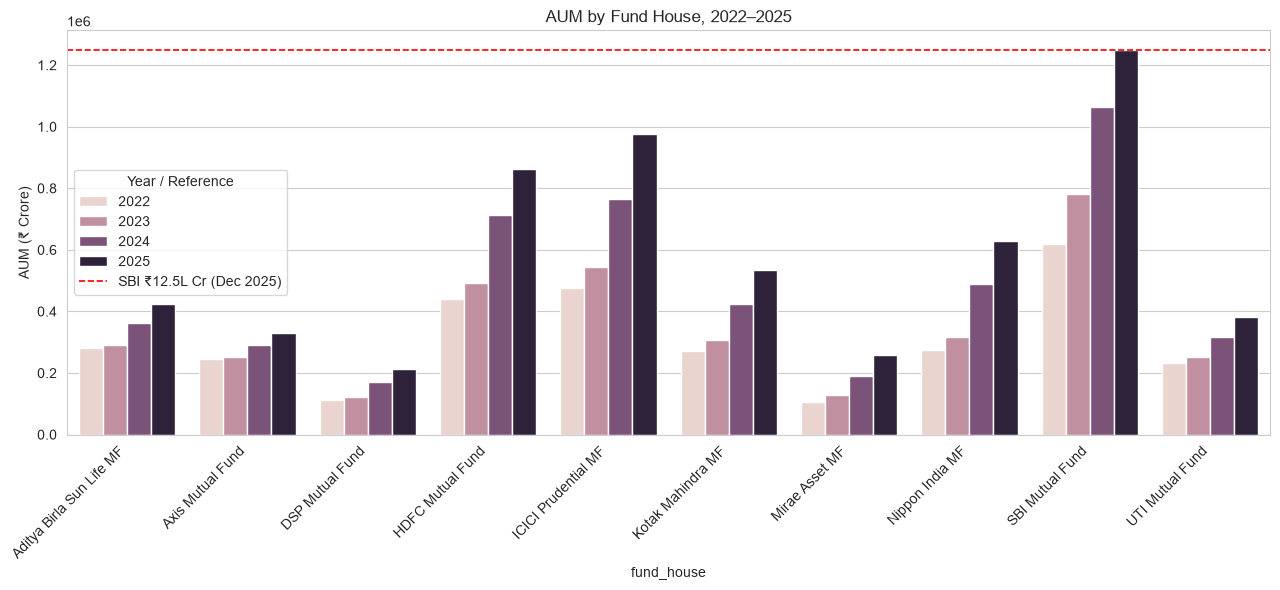

In [16]:
aum["year"] = aum["full_date"].dt.year

aum_yearly = aum.groupby(["fund_house","year"])["aum_crore"].mean().reset_index()

plt.figure(figsize=(13,6))
sns.barplot(data=aum_yearly, x="fund_house", y="aum_crore", hue="year")
plt.axhline(1250000, color="red", linestyle="--", linewidth=1.2, label="SBI ₹12.5L Cr (Dec 2025)")
plt.xticks(rotation=45, ha="right")
plt.title("AUM by Fund House, 2022–2025")
plt.ylabel("AUM (₹ Crore)")
plt.legend(title="Year / Reference")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "02_aum_growth_by_amc.png", dpi=150)
plt.show()

In [17]:
sip_sorted = sip.sort_values("full_date")

fig3 = px.line(sip_sorted, x="full_date", y="sip_inflow_crore",
               title="Monthly SIP Inflow (Jan 2022 – Dec 2025)")
fig3.add_scatter(x=["2025-12-01"], y=[31002], mode="markers+text",
                  text=["₹31,002 Cr — All-Time High"], textposition="top center",
                  marker=dict(size=12, color="red", symbol="star"))
fig3.update_layout(yaxis_title="SIP Inflow (₹ Crore)")
fig3.show()
plt.savefig(REPORTS_DIR / "03_sip_inflow.png", dpi=150)

<Figure size 640x480 with 0 Axes>

In [18]:
category_inflows = pd.read_csv("../data/raw/05_category_inflows.csv")
print(category_inflows.columns.tolist())
print(category_inflows.head())

['month', 'category', 'net_inflow_crore']
     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


In [19]:
pivot = category_inflows.pivot(index="category", columns="month", values="net_inflow_crore")
print(pivot.shape)
print(pivot.head())

(12, 12)
month            2024-04  2024-05  2024-06  2024-07  2024-08  2024-09  \
category                                                                
ELSS               466.0    553.0    472.0    471.0    499.0    537.0   
Flexi Cap         4947.0   5529.0   4478.0   4869.0   5562.0   5397.0   
Gilt               784.0    836.0    864.0    959.0    952.0    925.0   
Hybrid            2955.0   3487.0   3163.0   3291.0   3684.0   3015.0   
Large & Mid Cap   4214.0   4368.0   4610.0   5023.0   5411.0   4528.0   

month            2024-10  2024-11  2024-12  2025-01  2025-02  2025-03  
category                                                               
ELSS               537.0    571.0    521.0    516.0    437.0    500.0  
Flexi Cap         6004.0   6111.0   4654.0   5603.0   6068.0   4767.0  
Gilt               898.0    704.0    831.0    744.0    942.0    956.0  
Hybrid            3314.0   3264.0   3538.0   2967.0   3360.0   2830.0  
Large & Mid Cap   4581.0   5556.0   4878.0   48

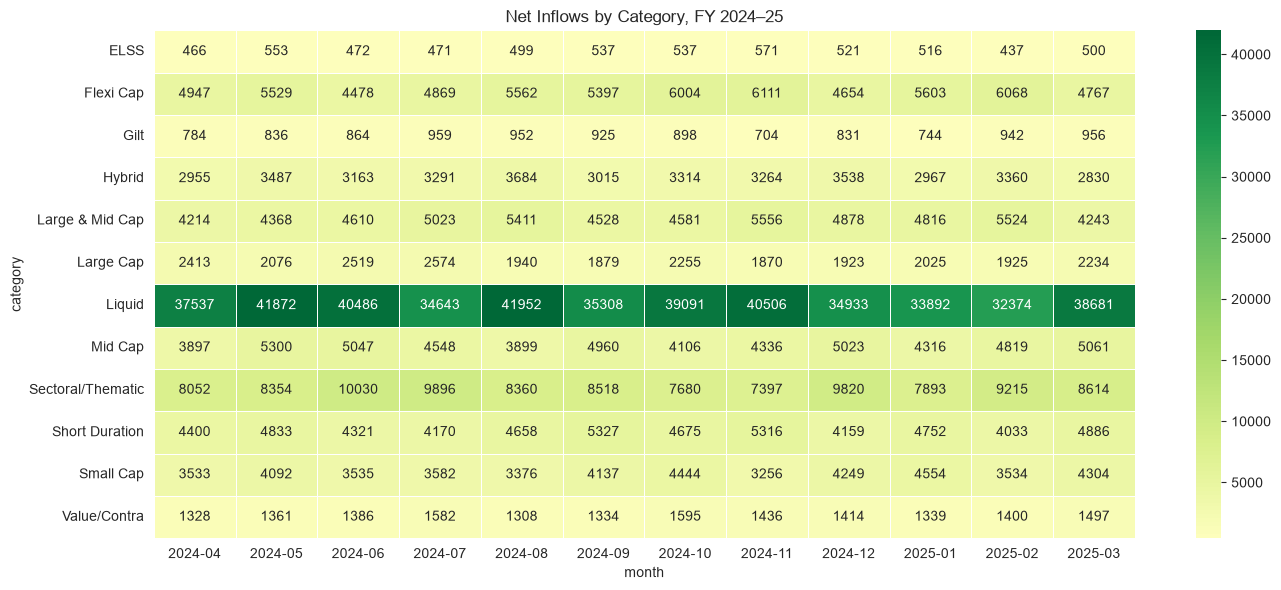

In [20]:
plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap="RdYlGn", center=0, annot=True, fmt=".0f", linewidths=0.5)
plt.title("Net Inflows by Category, FY 2024–25")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "04_category_heatmap.png", dpi=150)
plt.show()

In [21]:
# Step 1: Check current table structure (confirm investor_id and state columns DO exist, just empty)
from sqlalchemy import inspect
inspector = inspect(engine)
for col in inspector.get_columns("fact_transactions"):
    print(col["name"], col["type"])

transaction_id INTEGER
amfi_code INTEGER
date_id INTEGER
investor_id TEXT
transaction_type TEXT
amount_inr REAL
kyc_status TEXT
state TEXT


In [22]:
#Clear existing transaction data
from sqlalchemy import text
with engine.connect() as conn:
    conn.execute(text("DELETE FROM fact_transactions"))
    conn.commit()
print(pd.read_sql("SELECT COUNT(*) FROM fact_transactions", engine))  # should show 0

   COUNT(*)
0         0


In [24]:
txn_raw = pd.read_csv(DATA_RAW / "08_investor_transactions.csv", parse_dates=["transaction_date"])

In [25]:
print(txn_raw.columns.tolist())
print(txn_raw.head())
print(fund_master.columns.tolist())
print(dim_date.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female      

In [30]:
# Merge txn_raw with dim_date to get date_id from transaction_date
txn_merged = txn_raw.merge(
    dim_date[["date_id", "full_date"]],
    left_on="transaction_date",
    right_on="full_date",
    how="left"
)

print(txn_merged.shape)
print(txn_merged.columns.tolist())
print(txn_merged[["transaction_date", "full_date", "date_id"]].head())

txn_final = txn_merged[["amfi_code", "date_id", "investor_id", "transaction_type",
                          "amount_inr", "kyc_status", "state"]]

print(txn_final.shape)
print(txn_final.head())

(32778, 15)
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'date_id', 'full_date']
  transaction_date  full_date  date_id
0       2024-01-01 2024-01-01    18417
1       2024-01-01 2024-01-01    18417
2       2024-01-01 2024-01-01    18417
3       2024-01-01 2024-01-01    18417
4       2024-01-01 2024-01-01    18417
(32778, 7)
   amfi_code  date_id investor_id transaction_type  amount_inr kyc_status  \
0     119092    18417   INV003054              SIP        1834   Verified   
1     148567    18417   INV002952       Redemption      392882   Verified   
2     118636    18417   INV003420              SIP         912   Verified   
3     118634    18417   INV003436              SIP        1102    Pending   
4     119094    18417   INV004691          Lumpsum        8682    Pending   

         state  
0    Telangana  
1       Punjab  
2      Haryana  


In [31]:
#  Select only the columns fact_transactions actually needs, correctly named
print(txn_final.shape)
print(txn_final.head())
print("Nulls in investor_id:", txn_final["investor_id"].isna().sum())
print("Nulls in state:", txn_final["state"].isna().sum())
# Load into the table
txn_final.to_sql("fact_transactions", engine, if_exists="append", index=False)

# Verify
print(pd.read_sql("SELECT COUNT(*) FROM fact_transactions", engine))
print(pd.read_sql("SELECT investor_id, state, amount_inr FROM fact_transactions LIMIT 5", engine))

(32778, 7)
   amfi_code  date_id investor_id transaction_type  amount_inr kyc_status  \
0     119092    18417   INV003054              SIP        1834   Verified   
1     148567    18417   INV002952       Redemption      392882   Verified   
2     118636    18417   INV003420              SIP         912   Verified   
3     118634    18417   INV003436              SIP        1102    Pending   
4     119094    18417   INV004691          Lumpsum        8682    Pending   

         state  
0    Telangana  
1       Punjab  
2      Haryana  
3  Maharashtra  
4        Delhi  
Nulls in investor_id: 0
Nulls in state: 0
   COUNT(*)
0     32778
  investor_id        state  amount_inr
0   INV003054    Telangana      1834.0
1   INV002952       Punjab    392882.0
2   INV003420      Haryana       912.0
3   INV003436  Maharashtra      1102.0
4   INV004691        Delhi      8682.0


In [34]:
demo_lookup = txn_raw[["investor_id", "age_group", "gender", "city_tier"]].drop_duplicates(subset="investor_id")

print(demo_lookup.shape)
print(demo_lookup.head())

txn = txn.merge(demo_lookup, on="investor_id", how="left")
print(txn.shape)
print(txn[["investor_id","age_group","gender","city_tier"]].head())
print("Nulls in age_group:", txn["age_group"].isna().sum())

(5000, 4)
  investor_id age_group  gender city_tier
0   INV003054       56+  Female       T30
1   INV002952     18-25    Male       B30
2   INV003420     36-45    Male       B30
3   INV003436     36-45  Female       T30
4   INV004691     26-35    Male       T30
(32778, 12)
  investor_id age_group  gender city_tier
0   INV003054       56+  Female       T30
1   INV002952     18-25    Male       B30
2   INV003420     36-45    Male       B30
3   INV003436     36-45  Female       T30
4   INV004691     26-35    Male       T30
Nulls in age_group: 0


In [35]:
# Reload txn fresh from the now-fixed database table
txn = pd.read_sql("SELECT * FROM fact_transactions", engine)
txn = txn.merge(dim_date[["date_id","full_date"]], on="date_id", how="left")

print(txn.shape)
print(txn[["investor_id","state","amount_inr"]].head())
# Re-merge demographics (age_group, gender, city_tier)
txn = txn.merge(demo_lookup, on="investor_id", how="left")
print(txn.shape)
print(txn[["investor_id","age_group","gender","city_tier"]].head())
print("Nulls in age_group:", txn["age_group"].isna().sum())


(32778, 9)
  investor_id        state  amount_inr
0   INV003054    Telangana      1834.0
1   INV002952       Punjab    392882.0
2   INV003420      Haryana       912.0
3   INV003436  Maharashtra      1102.0
4   INV004691        Delhi      8682.0
(32778, 12)
  investor_id age_group  gender city_tier
0   INV003054       56+  Female       T30
1   INV002952     18-25    Male       B30
2   INV003420     36-45    Male       B30
3   INV003436     36-45  Female       T30
4   INV004691     26-35    Male       T30
Nulls in age_group: 0


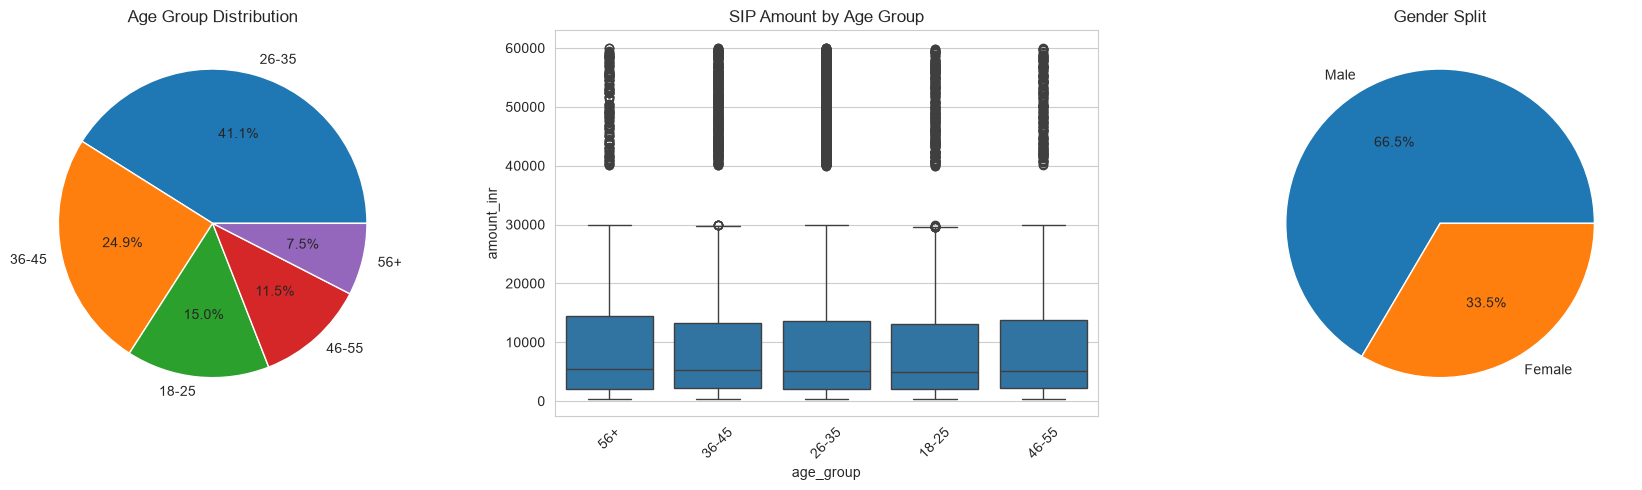

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
txn["age_group"].value_counts().plot.pie(autopct="%1.1f%%", ax=axes[0])
axes[0].set_title("Age Group Distribution")
axes[0].set_ylabel("")
sip_txn = txn[txn["transaction_type"]=="SIP"]
sns.boxplot(data=sip_txn, x="age_group", y="amount_inr", ax=axes[1])
axes[1].set_title("SIP Amount by Age Group")
axes[1].tick_params(axis="x", rotation=45)
txn["gender"].value_counts().plot.pie(autopct="%1.1f%%", ax=axes[2])
axes[2].set_title("Gender Split")
axes[2].set_ylabel("")
plt.tight_layout()
plt.savefig(REPORTS_DIR/"05_demographics.png", dpi=150)
plt.show()

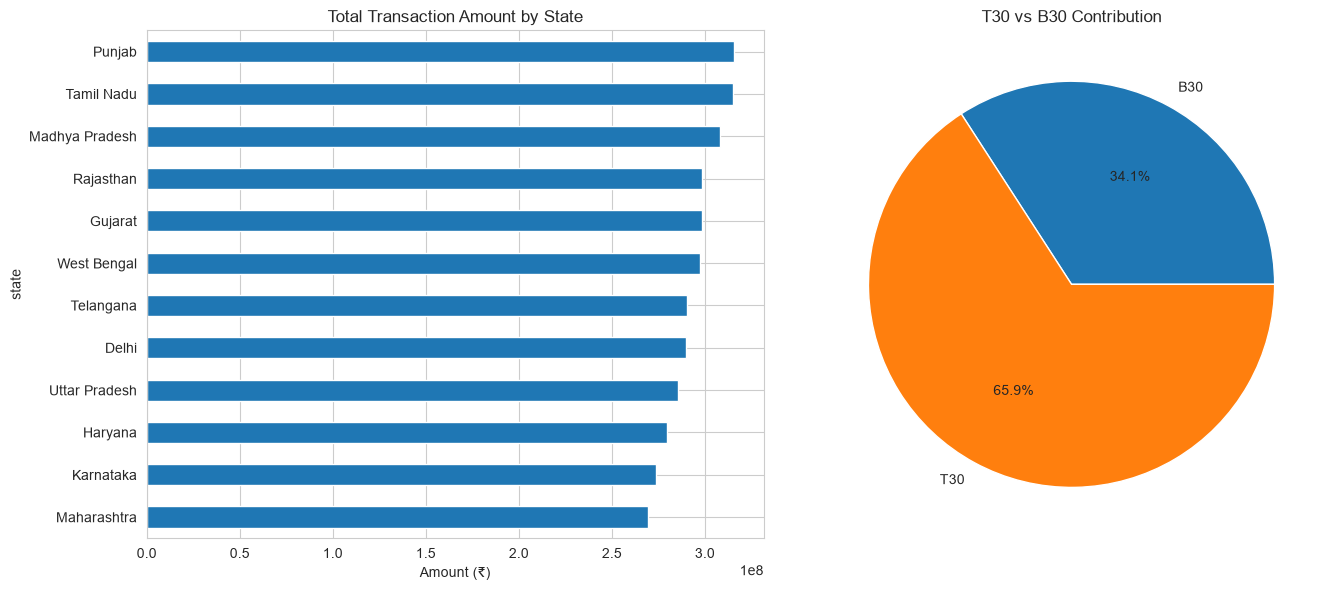

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
state_totals = txn.groupby("state")["amount_inr"].sum().sort_values()
state_totals.plot.barh(ax=axes[0])
axes[0].set_title("Total Transaction Amount by State")
axes[0].set_xlabel("Amount (₹)")
tier_totals = txn.groupby("city_tier")["amount_inr"].sum()
tier_totals.plot.pie(autopct="%1.1f%%", ax=axes[1])
axes[1].set_title("T30 vs B30 Contribution")
axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig(REPORTS_DIR/"06_geo_distribution.png", dpi=150)
plt.show()

In [38]:
folio = pd.read_csv(DATA_RAW/"06_industry_folio_count.csv")
print(folio.columns.tolist())
print(folio.head())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


In [39]:
folio["month"] = pd.to_datetime(folio["month"])
folio = folio.sort_values("month")
fig7 = px.line(folio, x="month", y="total_folios_crore",
               title="Total MF Folio Growth (2022–2025)")
fig7.add_scatter(x=[folio["month"].min()], y=[folio["total_folios_crore"].min()],
                  mode="markers+text", text=[f"{folio['total_folios_crore'].min():.2f} Cr (start)"],
                  textposition="bottom center", marker=dict(size=10, color="blue"))

fig7.add_scatter(x=[folio["month"].max()], y=[folio["total_folios_crore"].max()],
                  mode="markers+text", text=[f"{folio['total_folios_crore'].max():.2f} Cr (latest)"],
                  textposition="top center", marker=dict(size=10, color="red"))

fig7.update_layout(yaxis_title="Total Folios (₹ Crore)")
fig7.show()
plt.savefig(REPORTS_DIR/"07_folio_growth.png", dpi=150)

<Figure size 640x480 with 0 Axes>

In [40]:
nav_sorted = nav.sort_values(["amfi_code","full_date"])
nav_sorted["daily_return"] = nav_sorted.groupby("amfi_code")["nav"].pct_change()
top10 = fund_master["amfi_code"].head(10)
returns_wide = nav_sorted[nav_sorted["amfi_code"].isin(top10)].pivot(
    index="full_date", columns="scheme_name", values="daily_return")

scheme_name                                         ABSL Frontline Equity Fund - Regular - Growth  \
scheme_name                                                                                         
ABSL Frontline Equity Fund - Regular - Growth                                            1.000000   
ABSL Liquid Fund - Regular - Growth                                                     -0.006652   
ABSL Small Cap Fund - Regular - Growth                                                   0.010879   
HDFC Mid-Cap Opportunities Fund - Regular - Growth                                      -0.015645   
HDFC Short Term Debt Fund - Regular - Growth                                             0.025551   
HDFC Top 100 Fund - Regular Plan - Growth                                                0.028120   
Nippon India Large Cap Fund - Regular - Growth                                          -0.002855   
UTI Flexi Cap Fund - Regular - Growth                                                   -0.

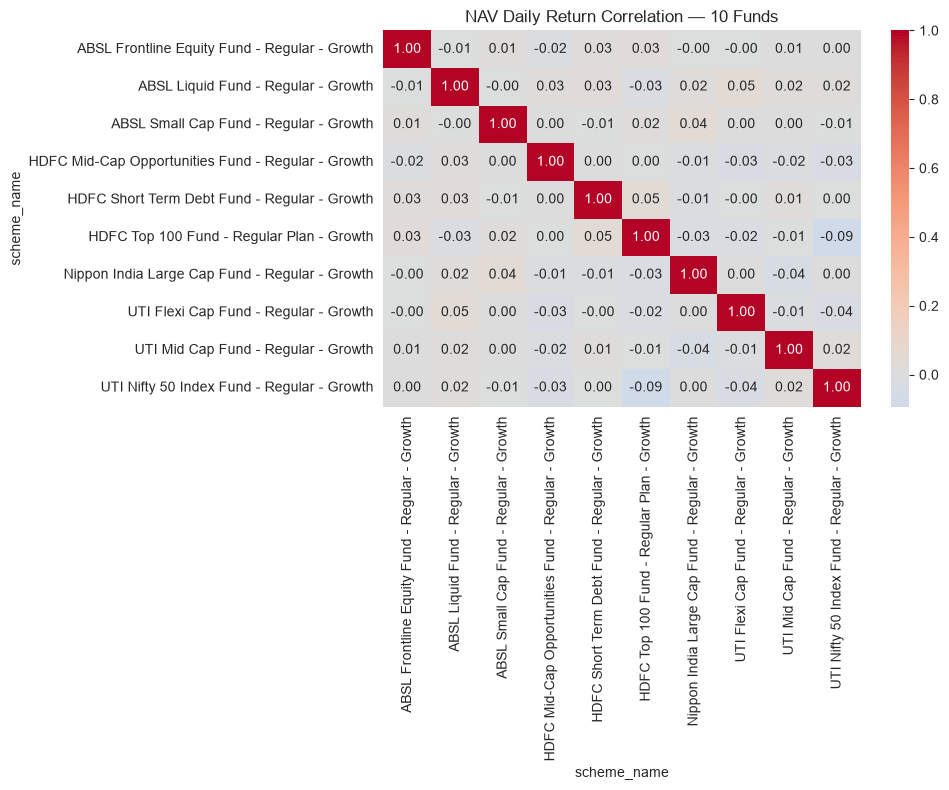

In [41]:
corr_matrix = returns_wide.corr()
print(corr_matrix)
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("NAV Daily Return Correlation — 10 Funds")
plt.tight_layout()
plt.savefig(REPORTS_DIR/"08_correlation_matrix.png", dpi=150)
plt.show()

In [42]:
print(holdings.columns.tolist())
print(holdings.head())

['amfi_code', 'stock_symbol', 'weight_pct', 'sector', 'date_id', 'full_date']
   amfi_code stock_symbol  weight_pct       sector  date_id  full_date
0     119551    POWERGRID       13.85    Utilities    19147 2025-12-31
1     119551     HDFCBANK       11.19      Banking    19147 2025-12-31
2     119551       GRASIM        9.90  Diversified    19147 2025-12-31
3     119551      DRREDDY        4.76       Pharma    19147 2025-12-31
4     119551   ASIANPAINT       10.25       Paints    19147 2025-12-31


sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64


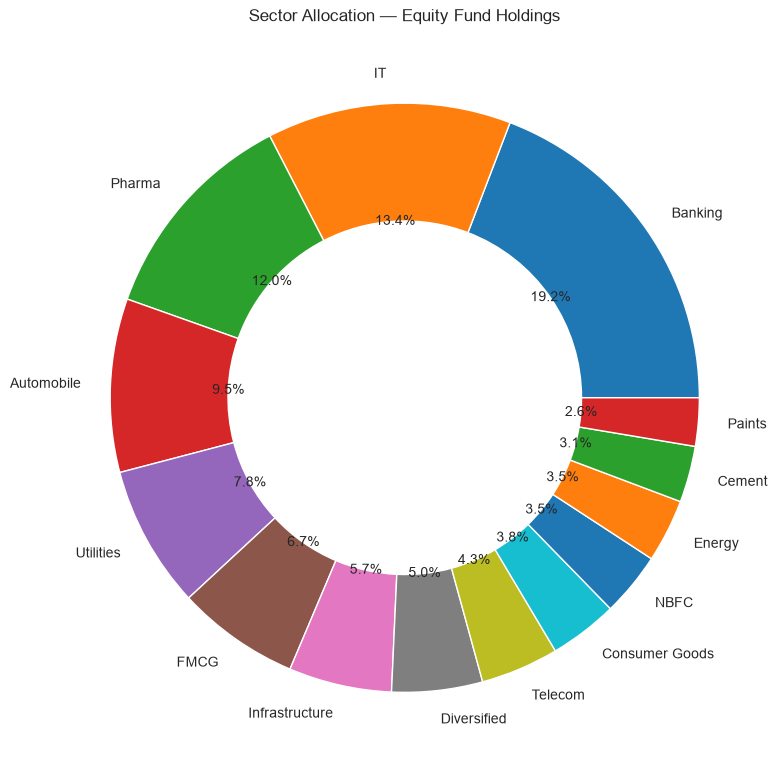

In [43]:
sector_weights = holdings.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)
print(sector_weights)
plt.figure(figsize=(8,8))
plt.pie(sector_weights, labels=sector_weights.index, autopct="%1.1f%%",
        wedgeprops=dict(width=0.4))
plt.title("Sector Allocation — Equity Fund Holdings")
plt.tight_layout()
plt.savefig(REPORTS_DIR/"09_sector_donut.png", dpi=150)
plt.show()

In [44]:
perf = performance.merge(fund_master[["amfi_code","scheme_name","category"]], on="amfi_code", how="left")

fig10 = px.scatter(perf, x="std_dev_ann_pct", y="return_3yr_pct", 
                    size="aum_crore", color="category", hover_name="scheme_name",
                    title="Risk vs Return — 3yr CAGR vs Volatility (bubble = AUM)")
fig10.show()
plt.savefig(REPORTS_DIR/"10_risk_return_scatter.png", dpi=150)

<Figure size 640x480 with 0 Axes>

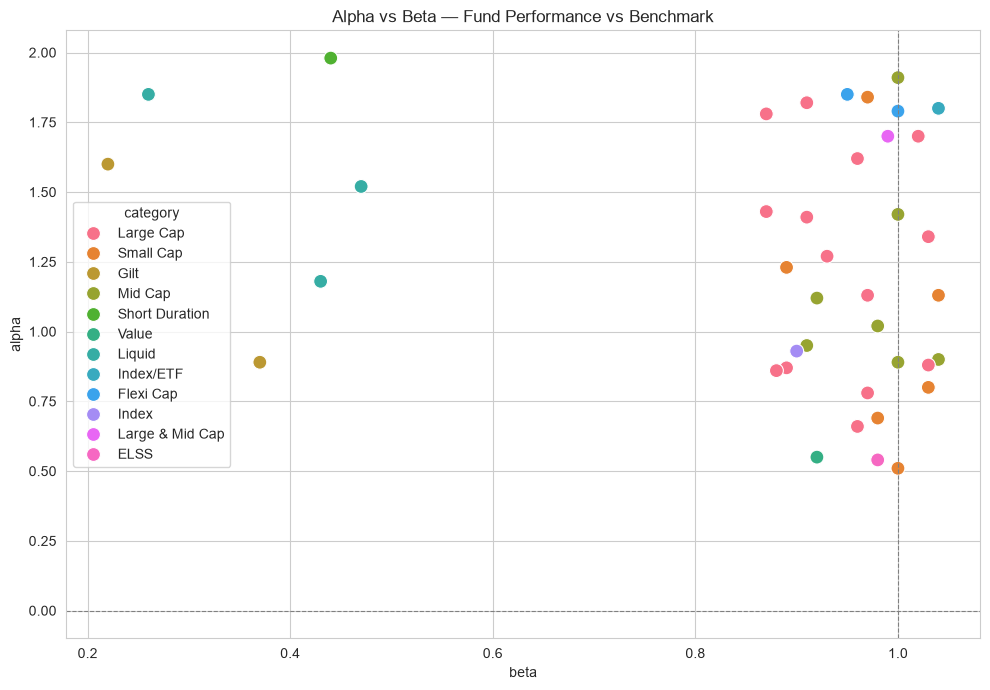

In [45]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=perf, x="beta", y="alpha", hue="category", s=100)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.axvline(1, color="gray", linestyle="--", linewidth=0.8)
plt.title("Alpha vs Beta — Fund Performance vs Benchmark")
plt.tight_layout()
plt.savefig(REPORTS_DIR/"11_alpha_beta_scatter.png", dpi=150)
plt.show()

In [48]:
expense = pd.read_csv(DATA_RAW/"01_fund_master.csv")
print(expense.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


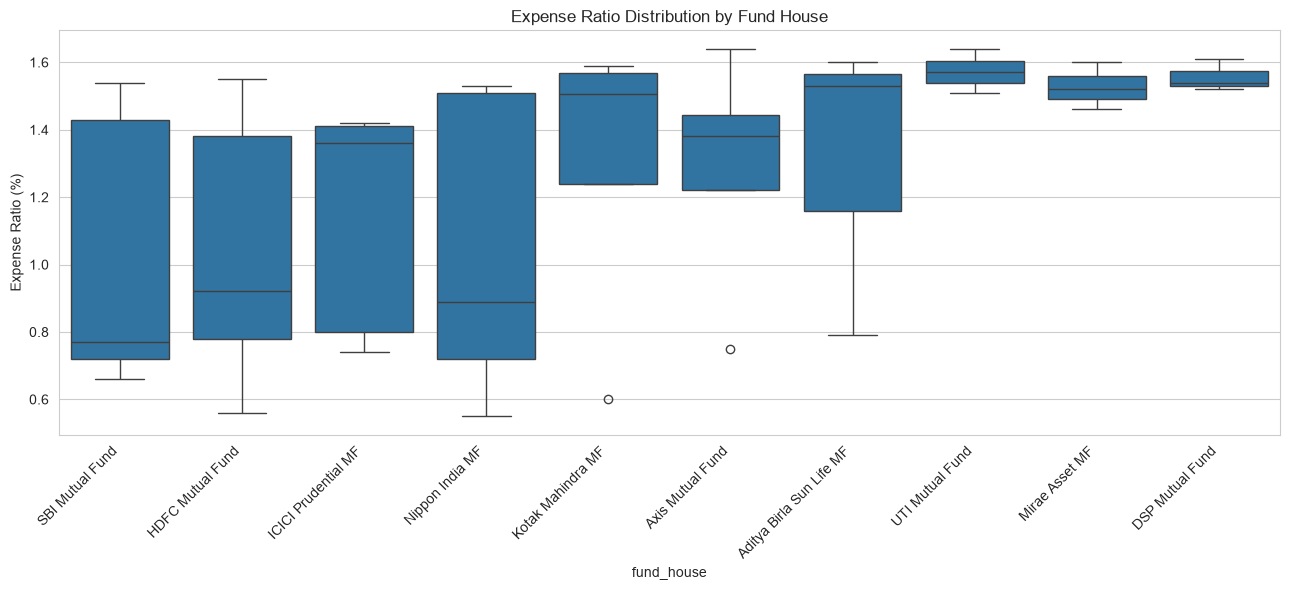

In [49]:
expense_lookup = expense[["amfi_code", "fund_house", "expense_ratio_pct"]]
plt.figure(figsize=(13,6))
sns.boxplot(data=expense_lookup, x="fund_house", y="expense_ratio_pct")
plt.xticks(rotation=45, ha="right")
plt.title("Expense Ratio Distribution by Fund House")
plt.ylabel("Expense Ratio (%)")
plt.tight_layout()
plt.savefig(REPORTS_DIR/"12_expense_ratio_by_fundhouse.png", dpi=150)
plt.show()